# MNIST from scratch

For now, the goal is only to understand what the MNIST dataset gives us.

No neural network yet.

In [142]:
from datasets import load_dataset

dataset = load_dataset("ylecun/mnist")

## 1. What did `load_dataset` give us?

Print the dataset and inspect the result.

In [143]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


The outer object contains two dataset splits: `train` and `test`.

Let's ask Python what the outer object actually is.

In [144]:
print(type(dataset))

<class 'datasets.dataset_dict.DatasetDict'>


## 2. Look at one row

Take the first row from the training dataset.

In [145]:
example = dataset["train"][0]
print(example)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x11F401590>, 'label': 5}


One row has two fields: `image` and `label`.

Now inspect the Python types.

In [146]:
print(type(example))
print(type(example["image"]))
print(type(example["label"]))

<class 'dict'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'int'>


## 3. Pull out the image and label

Because `example` is a normal Python dictionary, we can access its values by key.

In [147]:
image = example["image"]
label = example["label"]

print(label)

5


## 4. Look at the image

In a notebook, simply putting the image object on the last line displays it.

In [148]:
image

Inspect its dimensions and image mode.

In [149]:
print(image.size)
print(image.mode)

(28, 28)
L


## 5. Turn the image into numbers

The image is currently a PIL image object. Convert it into a NumPy array.

In [150]:
import numpy as np

pixels = np.array(image)

Inspect the array.

In [151]:
print(type(pixels))
print(pixels.shape)

<class 'numpy.ndarray'>
(28, 28)


Find the smallest and largest pixel values.

In [152]:
print(pixels.min())
print(pixels.max())

0
255


## 6. Inspect individual pixels

`pixels[row][column]` gives one pixel value.

In [153]:
print(pixels[0][0])
print(pixels[14][14])

0
240


Try changing the coordinates and poking around.

## 7. Draw the number grid as an image

Matplotlib can interpret the 28 × 28 array as image data.

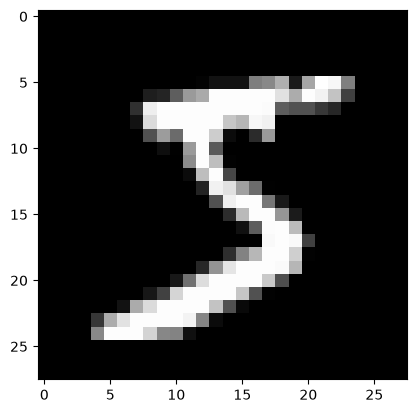

In [154]:
import matplotlib.pyplot as plt

plt.imshow(pixels, cmap="gray")
plt.show()

The important connection so far:

`PIL image → 28 × 28 NumPy array → visible image`

The array contains 784 pixel brightness values. We have not built or trained a neural network yet.

In [155]:
inputs = pixels.flatten()

print(inputs.shape)

(784,)


Now, let's initialize weights for the 1st neuron of the 1st hidden layer. We use randn(784) instead of 0 because:

Random weights give each neuron a slightly different starting point:

neuron 1 starts looking one way
neuron 2 starts looking another way
neuron 3 starts looking another way

Training can then push them toward different useful patterns. We can test this later too.

In [156]:
weights = np.random.randn(784)

print(weights.shape)

(784,)


We calculate the output of this neuron now by:

1) Calculate weighted sum

2) add a bias

3) An activation function to force the output into a desired range

In [157]:
# calculate the weighted sum
weighted_sum = sum(inputs * weights)

print(weighted_sum)
print(weighted_sum.shape)

bias = np.random.randn()

# z is a commonly used variable for the pre-activation value in neural networks
z = weighted_sum + bias

print(z)
print(z.shape)

4859.393312366124
()
4859.8975085844795
()


Now, let's implement the activation function: Sigmoid, that is defined as: $$f(x) = \frac{1}{1 + e^{-x}}$$

In [158]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Let's call the activation function with some sample inputs and also on our pre-activation output (z)

In [159]:
print(sigmoid(-5))
print(sigmoid(1))
print(sigmoid(5))
print(sigmoid(10))
print(sigmoid(z))

0.0066928509242848554
0.7310585786300049
0.9933071490757153
0.9999546021312976
1.0


Now, let's initialize the full weights matrix for the first hidden layer. We will have 16 neurons in the 1st layer, so our weights matrix will be: (16, 784)

Each row is the set of weights corresponding with the nth neuron

In [160]:
weights = np.random.randn(16, 784)

print(weights.shape)

(16, 784)


Now, we do the matrix multiplication to get the output from the first layer

In [161]:
first_layer_outputs = sigmoid(weights @ inputs + bias)

print(first_layer_outputs.shape)
print(first_layer_outputs)

(16,)
[1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1.]


/var/folders/56/k25md8cd1gsd0z_7tvy5ylh80000gn/T/ipykernel_7691/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


The above results in overflow because for each neuron, we are doing:

(the input, which is between the range 0-255) * (weight which is in the range -1 to 1)

255 * 1 + 180 + -0.9 .... 

and this can lead to values like z = -5000

and for sigmoid, it will end up calculating e^5000 which is a really large number causing overlow. for this reason, we will normalize the 0-255 values into 0-1 range.

## Starting over

In [182]:
inputs = pixels.flatten() / 255

first_layer_outputs = sigmoid(weights @ inputs + bias)
print(first_layer_outputs.shape)
print(first_layer_outputs)

(16,)
[7.02724628e-01 2.08526161e-06 3.47913126e-04 2.97674999e-05
 9.99999750e-01 3.36290880e-05 5.10317161e-03 6.85401177e-03
 7.72393026e-01 9.50686673e-01 1.15784343e-04 2.59943304e-04
 3.81000046e-06 9.33560261e-01 9.99999078e-01 9.70372611e-01]


In [183]:
output_layer_weights = np.random.randn(10, 16)
output_layer_biases = np.zeros(10)

output_layer_outputs = sigmoid(output_layer_weights @ first_layer_outputs + output_layer_biases)
print(output_layer_outputs.shape)
print(output_layer_outputs)

(10,)
[0.2915704  0.11486367 0.63258968 0.98170125 0.70373279 0.69011532
 0.97845408 0.63456825 0.91136955 0.97414853]


In [184]:
prediction = np.argmax(output_layer_outputs)

# now we can compare the prediction with the actual label
print(f"Prediction: {prediction}")
print(f"Actual: {label}")

Prediction: 3
Actual: 5


In [185]:
target = np.zeros(10)
target[label] = 1
error = target - output_layer_outputs

print(target)
print(error)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[-0.2915704  -0.11486367 -0.63258968 -0.98170125 -0.70373279  0.30988468
 -0.97845408 -0.63456825 -0.91136955 -0.97414853]


In [186]:
loss = np.mean(error ** 2)
print(loss)

0.5192991454381767


First, prove that changing one weight changes the loss.

Pick one output-layer weight:

In [187]:
row = 5
column = 0

That means:

weight from hidden neuron 0
to output neuron 5

Save it's curent value

In [188]:
original_value = output_layer_weights[row][column]

print(original_value)

-0.5106351574153133


In [189]:
# Increase that by a small number
epsilon = 0.01
output_layer_weights[row][column] += epsilon

# redo the forward pass, check the loss again
plus_epsilon_output = sigmoid(output_layer_weights @ first_layer_outputs + output_layer_biases)
plus_epsilon_error = target - plus_epsilon_output
plus_epsilon_loss = np.mean(plus_epsilon_error ** 2)

print(plus_epsilon_loss)


0.5192063551574416


Now calculate the change in loss. if loss decreased, we want to keep the episilon addition.
if loss incrased, we want to go in the opposite direction and subtract epsilon

In [190]:
change_in_loss = plus_epsilon_loss - loss
change_in_loss

np.float64(-9.279028073505557e-05)

Also, the size of the epsilon here matters.

1) Loss going up/down tells us if epsilon should be added/subtracted.
2) But how much that epsilon should be is depended on how much the loss goes up and down at that point - i.e. the gradient of the loss with respect to that one parameter.

i.e. epsolion ~ gradient
or, epsilon = learning_rate * gradient 

Where learning rate is a constant we choose, that determines how big the jump are proportional to the gradient. There is no universal correct value. You usually choose it experimentally by watching training:

- Loss falls steadily: probably reasonable.
- Loss jumps around or explodes: probably too high.
- Loss barely changes: possibly too low.

In [191]:
gradient = (plus_epsilon_loss - loss) / epsilon

learning_rate = 0.01
output_layer_weights[row][column] = original_value - learning_rate * gradient

print('original value:', original_value)
print('gradient:', gradient)
print('updated value:', output_layer_weights[row][column])


original value: -0.5106351574153133
gradient: -0.009279028073505557
updated value: -0.5105423671345782


For the whole output layer:

$$
\text{loss}
=
\operatorname{mean}
\left(
(\text{output\_activations} - \text{target})^2
\right)
$$

The gradient of the loss with respect to the full output activation vector is:

$$
\frac{\partial \text{loss}}
{\partial \text{output\_activations}}
=
\frac{2}{10}
\left(
\text{output\_activations}
-
\text{target}
\right)
$$

Because:

$$
\text{output\_activations}
=
\sigma(\text{output\_z})
$$

and:

$$
\frac{\partial \text{output\_activations}}
{\partial \text{output\_z}}
=
\text{output\_activations}
\odot
\left(
1-\text{output\_activations}
\right)
$$

the chain rule gives:

$$
\text{output\_delta}
=
\frac{\partial \text{loss}}
{\partial \text{output\_z}}
$$

$$
\text{output\_delta}
=
\frac{\partial \text{loss}}
{\partial \text{output\_activations}}
\odot
\text{output\_activations}
\odot
\left(
1-\text{output\_activations}
\right)
$$

Now we use `output_delta` to calculate the gradients for the output-layer bias and weights.

The output layer computes:

$$
\text{output\_z}
=
\text{output\_weights}
\cdot
\text{hidden\_activations}
+
\text{output\_bias}
$$

Because the bias is added directly to $\text{output\_z}$:

$$
\frac{\partial \text{output\_z}}
{\partial \text{output\_bias}}
=
1
$$

Therefore:

$$
\frac{\partial \text{loss}}
{\partial \text{output\_bias}}
=
\text{output\_delta}
$$

For the output-layer weights:

$$
\frac{\partial \text{output\_z}}
{\partial \text{output\_weights}}
=
\text{hidden\_activations}
$$

Therefore:

$$
\frac{\partial \text{loss}}
{\partial \text{output\_weights}}
=
\text{output\_delta}
\otimes
\text{hidden\_activations}
$$

where $\otimes$ means the outer product.

In code:

```python
output_layer_weight_gradient = np.outer(
    output_delta,
    hidden_activations,
)

output_layer_bias_gradient = output_delta
```